<a href="https://colab.research.google.com/github/Nancyrana1/Deep-Learning/blob/main/Pytorch_LinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.optim as optim

In [37]:
X =torch.rand((100,1))*100
y = 3*X +10 + torch.rand(100,1)*10

# NORMALISE THE DATA SINCE IT IS SCATTERED
X = X/X.max()

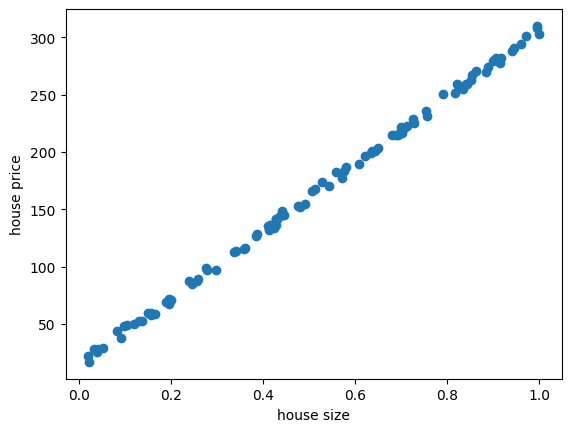

In [38]:
plt.scatter(X,y)
plt.xlabel("house size")
plt.ylabel("house price")
plt.show()

In [39]:
class LinearRegressionModel(nn.Module):
  def __init__(self, in_features, out_features):
    super(LinearRegressionModel,self).__init__()
    self.linear=nn.Linear(in_features,out_features)
  def forward(self, x):
    return self.linear(x)   #y_pred = wx + b

In [40]:
model = LinearRegressionModel(1,1)
criterion = nn.MSELoss()

optimizer = optim.SGD(model.parameters(), lr = 0.01)

In [41]:
epochs = 4000
losses = []


for epoch in range(epochs):
  y_pred = model(X)
  loss = criterion(y_pred, y)
  losses.append(loss.item())

  loss.backward()
  optimizer.step()
  optimizer.zero_grad()


  if epoch % 100 ==0:
    print(f'Epoch : [ {epoch}/epochs], loss: {loss.item():.4f}')

Epoch : [ 0/epochs], loss: 35524.0312
Epoch : [ 100/epochs], loss: 3249.5757
Epoch : [ 200/epochs], loss: 2377.6572
Epoch : [ 300/epochs], loss: 1833.4956
Epoch : [ 400/epochs], loss: 1414.7706
Epoch : [ 500/epochs], loss: 1092.0503
Epoch : [ 600/epochs], loss: 843.3169
Epoch : [ 700/epochs], loss: 651.6086
Epoch : [ 800/epochs], loss: 503.8524
Epoch : [ 900/epochs], loss: 389.9711
Epoch : [ 1000/epochs], loss: 302.1986
Epoch : [ 1100/epochs], loss: 234.5493
Epoch : [ 1200/epochs], loss: 182.4098
Epoch : [ 1300/epochs], loss: 142.2241
Epoch : [ 1400/epochs], loss: 111.2513
Epoch : [ 1500/epochs], loss: 87.3794
Epoch : [ 1600/epochs], loss: 68.9805
Epoch : [ 1700/epochs], loss: 54.7999
Epoch : [ 1800/epochs], loss: 43.8704
Epoch : [ 1900/epochs], loss: 35.4464
Epoch : [ 2000/epochs], loss: 28.9531
Epoch : [ 2100/epochs], loss: 23.9493
Epoch : [ 2200/epochs], loss: 20.0926
Epoch : [ 2300/epochs], loss: 17.1201
Epoch : [ 2400/epochs], loss: 14.8291
Epoch : [ 2500/epochs], loss: 13.0634
Ep

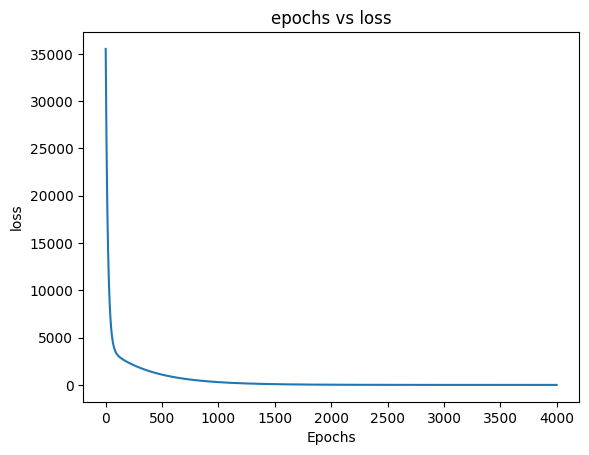

In [42]:
plt.plot(range(epochs),losses)
plt.xlabel("Epochs")
plt.ylabel("loss")
plt.title("epochs vs loss")
plt.show()

In [43]:
list(model.parameters())

[Parameter containing:
 tensor([[290.7966]], requires_grad=True),
 Parameter containing:
 tensor([15.3808], requires_grad=True)]

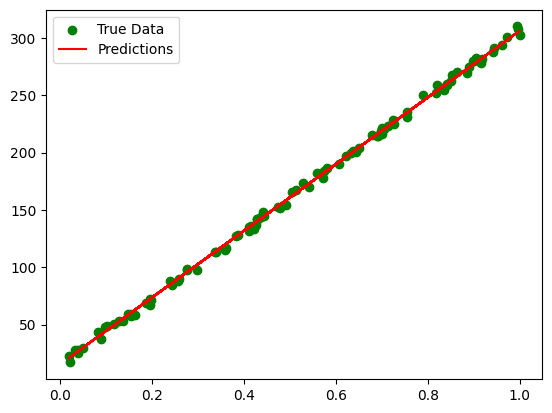

In [44]:
predicted = model(X).detach().numpy()
plt.scatter(X,y, label = 'True Data', color = 'Green')
plt.plot(X, predicted, label = "Predictions", color = 'red')
plt.legend()
plt.show()